# Stock Market Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on historical stock market data.

Objectives:

- Load and inspect the dataset
- Visualize stock price trends
- Analyze trading volume
- Compute technical indicators (RSI and MACD)
- Identify patterns in stock price movements

Dataset size: 11,108 rows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.set_style("darkgrid")

<Figure size 1200x600 with 0 Axes>

In [3]:
df = pd.read_csv("data/data.csv")

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,12-12-1980,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,15-12-1980,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,16-12-1980,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,17-12-1980,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,18-12-1980,0.091530,0.118862,0.119420,0.118862,0.118862,73449600


In [4]:
df.shape

(11107, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11107 entries, 0 to 11106
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11107 non-null  object 
 1   Adj Close  11107 non-null  float64
 2   Close      11107 non-null  float64
 3   High       11107 non-null  float64
 4   Low        11107 non-null  float64
 5   Open       11107 non-null  float64
 6   Volume     11107 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 607.5+ KB


In [6]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,11107.000000,11107.000000,11107.000000,11107.000000,11107.000000,1.110700e+04
mean,23.522229,24.357607,24.598169,24.092608,24.339076,3.154341e+08
std,49.767881,50.217498,50.691902,49.682631,50.166818,3.348735e+08
min,0.037815,0.049107,0.049665,0.049107,0.049665,0.000000e+00
25%,0.243402,0.300290,0.306362,0.292411,0.300090,1.111164e+08
50%,0.446682,0.542411,0.553393,0.534598,0.542679,2.036944e+08
75%,18.260086,21.397143,21.569285,21.115715,21.367679,3.960418e+08
max,259.019989,259.019989,260.100006,257.630005,258.190002,7.421641e+09


In [7]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600


In [8]:
df.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

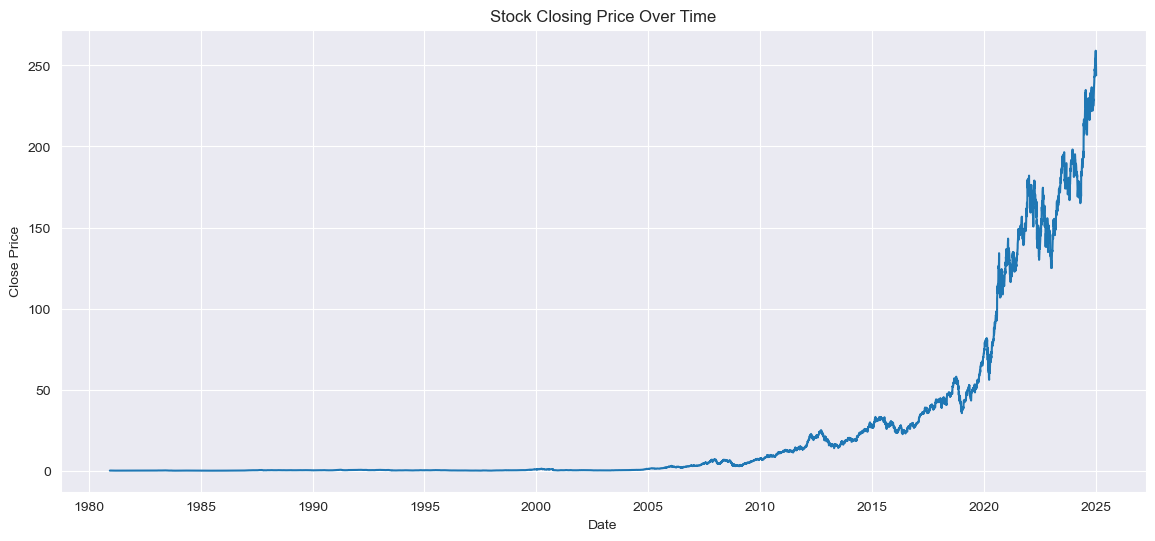

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df["Close"])

plt.title("Stock Closing Price Over Time")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()

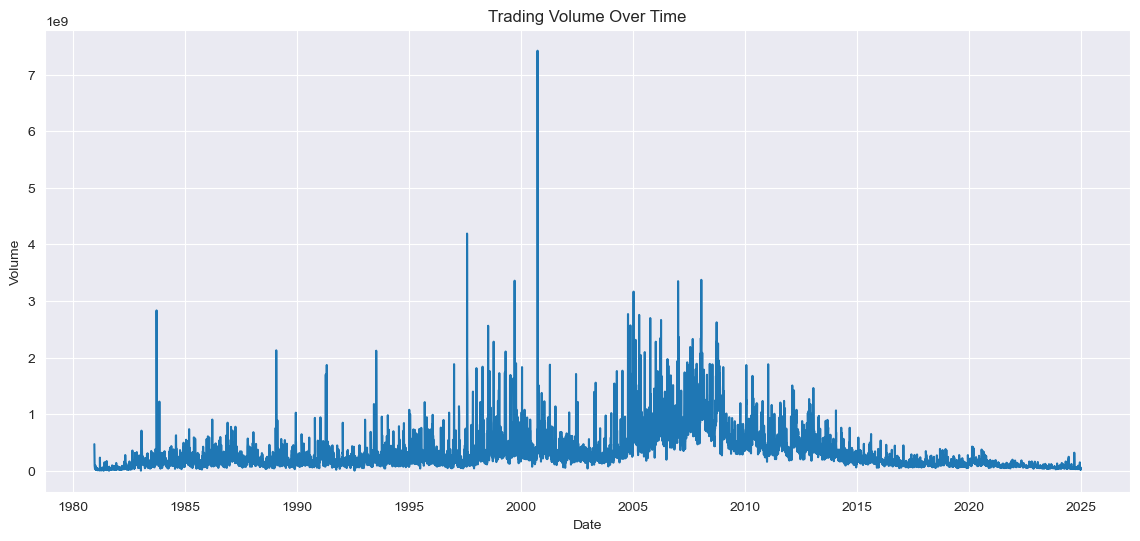

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df["Volume"])

plt.title("Trading Volume Over Time")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.show()

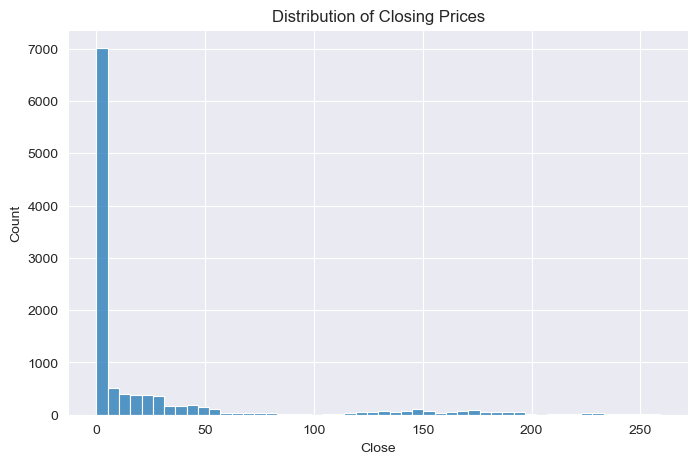

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Close"], bins=50)

plt.title("Distribution of Closing Prices")

plt.show()

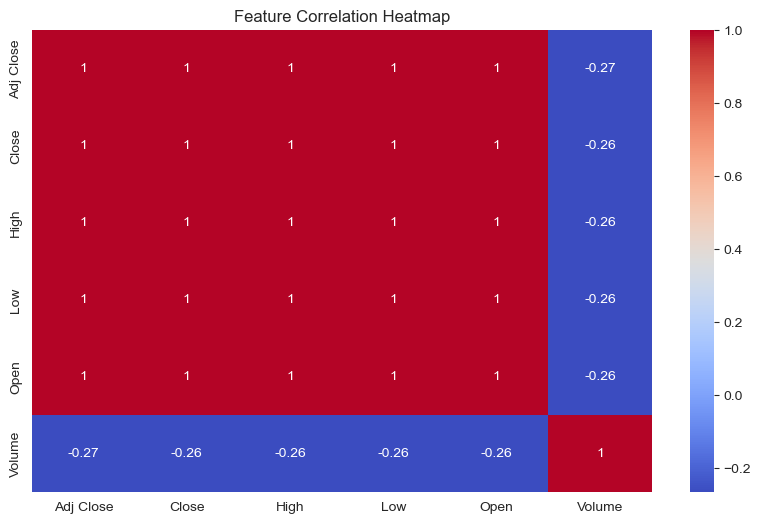

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [13]:
def compute_rsi(series, period=14):

    delta = series.diff()

    gain = delta.clip(lower=0)

    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()

    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi


df["RSI"] = compute_rsi(df["Close"])

df.tail()

,Adj Close,Close,High,Low,Open,Volume,RSI
Date,,,,,,,
2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,69.300654
2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,58.382041
2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,53.982563
2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000,46.576760
2025-01-03,243.860001,243.860001,244.179993,241.889999,243.369995,15135053,44.474377


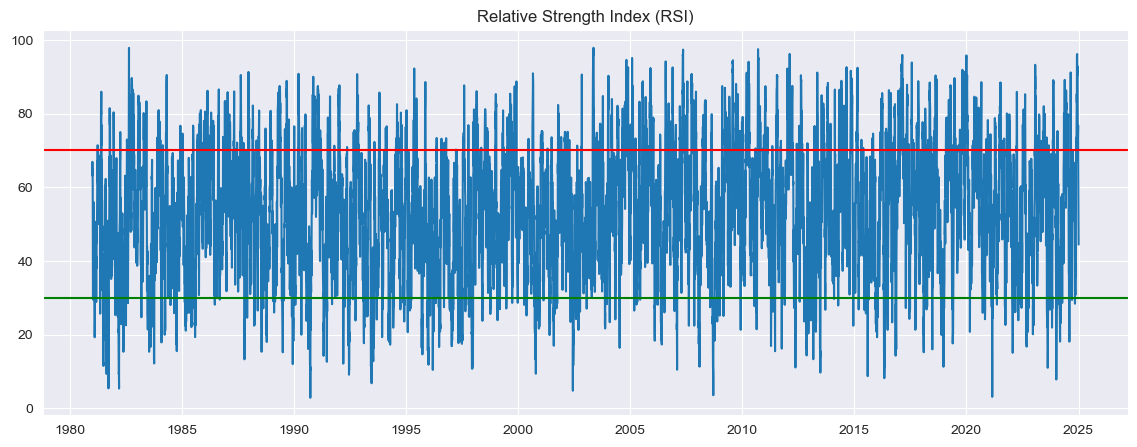

In [14]:
plt.figure(figsize=(14,5))

plt.plot(df["RSI"])

plt.axhline(70, color="red")

plt.axhline(30, color="green")

plt.title("Relative Strength Index (RSI)")

plt.show()

In [15]:
ema12 = df["Close"].ewm(span=12, adjust=False).mean()

ema26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema12 - ema26

df["Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df.tail()

,Adj Close,Close,High,Low,Open,Volume,RSI,MACD,Signal
Date,,,,,,,,,
2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,69.300654,6.126376,5.667139
2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,58.382041,5.659474,5.665606
2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,53.982563,5.087179,5.549921
2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000,46.576760,4.056724,5.251281
2025-01-03,243.860001,243.860001,244.179993,241.889999,243.369995,15135053,44.474377,3.203954,4.841816


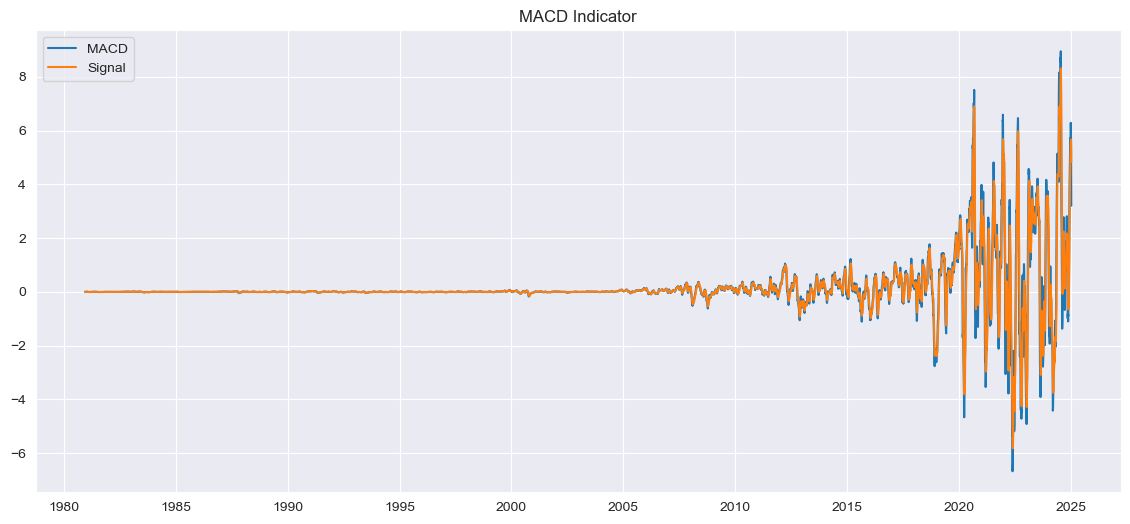

In [16]:
plt.figure(figsize=(14,6))

plt.plot(df["MACD"], label="MACD")

plt.plot(df["Signal"], label="Signal")

plt.legend()

plt.title("MACD Indicator")

plt.show()

In [17]:
df["MA50"] = df["Close"].rolling(window=50).mean()

df["MA200"] = df["Close"].rolling(window=200).mean()

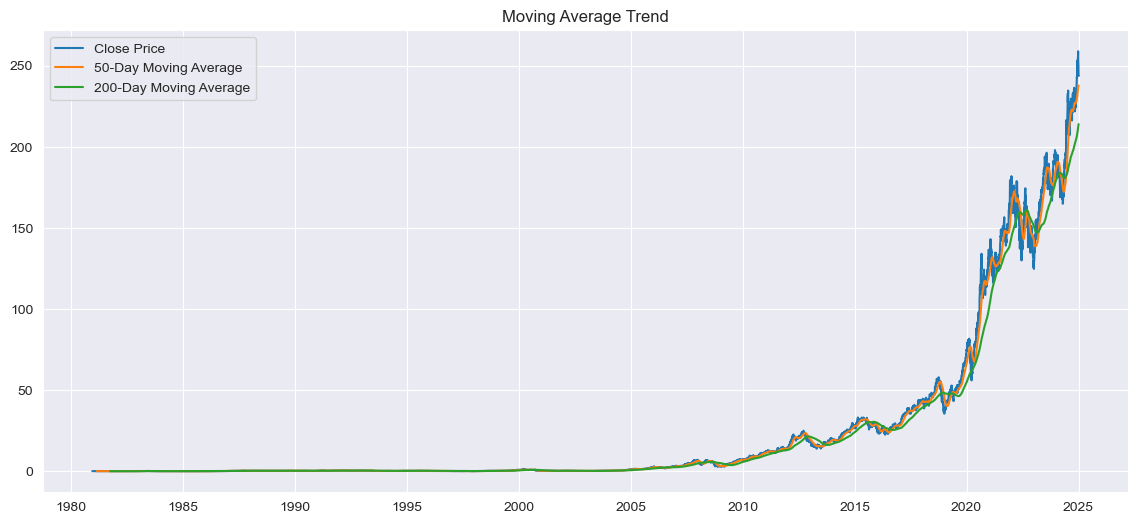

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df["Close"], label="Close Price")

plt.plot(df["MA50"], label="50-Day Moving Average")

plt.plot(df["MA200"], label="200-Day Moving Average")

plt.legend()

plt.title("Moving Average Trend")

plt.show()

# Key Insights

1. Stock prices show long-term upward trends.
2. Trading volume fluctuates significantly across periods.
3. RSI highlights periods of overbought and oversold conditions.
4. MACD helps identify potential trend reversals.
5. Moving averages smooth out noise and highlight long-term trends.

These insights help inform forecasting models such as ARIMA, Prophet, and LSTM.